# 01. Basic Survival Analysis with `lifelines`

## Introduction
**Survival Analysis** is a branch of statistics for analyzing the expected duration of time until one or more events happen, such as death in biological organisms and failure in mechanical systems.

### Key Concepts
1. **Time-to-Event ($T$)**: The time from a starting point (e.g., diagnosis, machine start) to the event of interest.
2. **Event ($E$)**: The occurrence of interest (e.g., death, failure, churn). Usually binary (1 = occurred, 0 = not occurred).
3. **Censoring**: The key differentiator of survival analysis. 
   - **Right Censoring**: The most common type. The event has NOT occurred by the end of the study. We only know $T > t_{end}$.

### Goal
In this notebook, we will:
1. Load a survival dataset.
2. Estimate the **Survival Function** using the **Kaplan-Meier Estimator**.
3. Compare survival curves between groups using the **Log-Rank Test**.
4. Model the effect of covariates using the **Cox Proportional Hazards Model**.

In [2]:
# Install lifelines if not already installed
# !pip install lifelines pandas matplotlib numpy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from lifelines.datasets import load_lung

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Data
We will use the **NCCTG Lung Cancer Dataset**. 
- `time`: Survival time in days.
- `status`: Censoring status (1=dead, 0=censored).
- `sex`: Male=1, Female=2.
- Other covariates: `age`, `ph.ecog` (ECOG performance score), etc.

In [5]:
data = load_lung()

# Drop missing values for simplicity in this intro
data = data.dropna()

# Map status to boolean (True if event happened) just for clarity, though lifelines handles 0/1
# 1: Censored, 2: Dead -> Remap to 0: Censored, 1: Dead
data['status'] = data['status'] - 1

print(f"\nDataset shape: {data.shape}")
data.head()


Dataset shape: (167, 10)


,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
1,3.0,455,0,68,1,0.0,90.0,90.0,1225.0,15.0
3,5.0,210,0,57,1,1.0,90.0,60.0,1150.0,11.0
5,12.0,1022,-1,74,1,1.0,50.0,80.0,513.0,0.0
6,7.0,310,0,68,2,2.0,70.0,60.0,384.0,10.0
7,11.0,361,0,71,2,2.0,60.0,80.0,538.0,1.0


## 2. Kaplan-Meier Estimator
The **Kaplan-Meier (KM)** estimator is a non-parametric statistic used to estimate the survival function $S(t)$ from lifetime data.

$$S(t) = P(T > t)$$

It does not assume any underlying distribution (like Normal or Exponential).

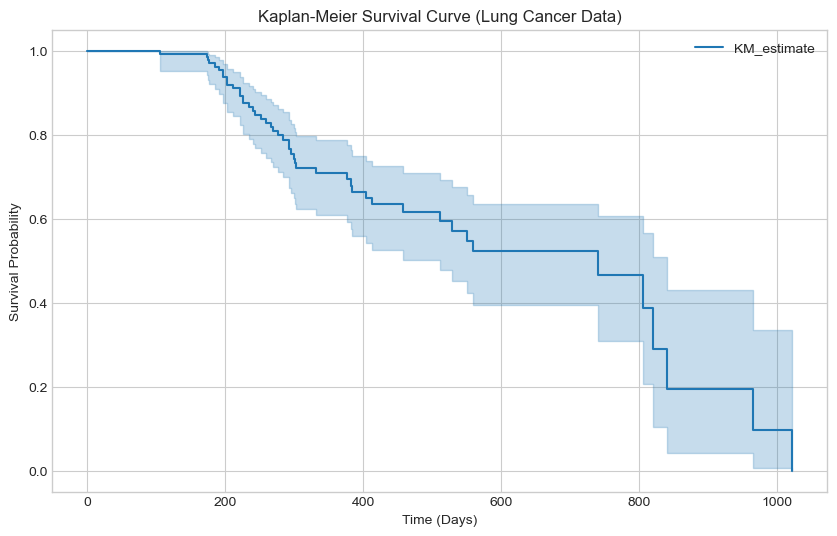

In [6]:
kmf = KaplanMeierFitter()

# Fit the data
kmf.fit(durations=data['time'], event_observed=data['status'])

# Plot the survival function
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve (Lung Cancer Data)")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

### Interpretation
- The y-axis represents the probability of surviving past time $t$.
- The steps go down whenever an event (death) occurs.
- The shaded area represents the confidence interval.
- **Median Survival Time**: The time at which 50% of the population has experienced the event.

In [7]:
print(f"Median Survival Time: {kmf.median_survival_time_} days")

Median Survival Time: 740.0 days


## 3. Comparing Groups (Log-Rank Test)
Do men and women have different survival rates?
We can split the data by `sex` (1=Male, 2=Female) and plot two KM curves.

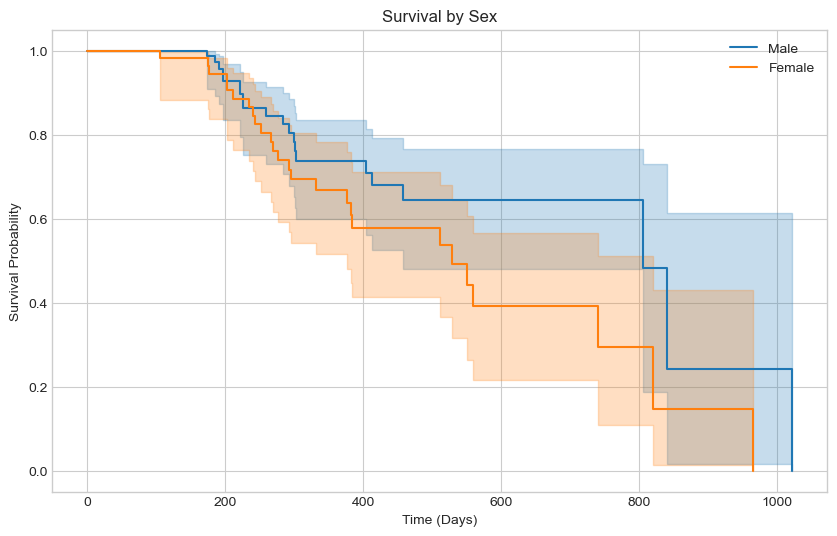

In [8]:
male = data[data['sex'] == 1]
female = data[data['sex'] == 2]

kmf_m = KaplanMeierFitter()
kmf_f = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

# Fit and plot Male
kmf_m.fit(male['time'], event_observed=male['status'], label='Male')
kmf_m.plot_survival_function()

# Fit and plot Female
kmf_f.fit(female['time'], event_observed=female['status'], label='Female')
kmf_f.plot_survival_function()

plt.title("Survival by Sex")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.show()

### Log-Rank Test
Visually, the curves look different. But is the difference statistically significant?
The **Log-Rank test** compares the survival distributions of two or more groups.
- $H_0$: There is no difference between the survival curves.
- $H_a$: There is a difference.

In [11]:
results = logrank_test(male['time'], female['time'], 
                       event_observed_A=male['status'], 
                       event_observed_B=female['status'])

results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           2.97 0.09      3.56

If p-value < 0.05, we reject the null hypothesis and conclude there is a significant difference in survival between males and females.

## 4. Cox Proportional Hazards Model
The Log-Rank test only tells us *if* there is a difference, not *how much*. 
The **Cox Proportional Hazards (Cox PH)** model allows us to regress survival time on multiple covariates (Age, Sex, ECOG score, etc.).

$$h(t|x) = h_0(t) \exp(\beta_1 x_1 + ... + \beta_k x_k)$$

- $\exp(\beta_i)$ is the **Hazard Ratio (HR)**.

In [12]:
# Preprocessing for Cox Model
# Cox model works best with dummy variables for categoricals, but 'sex' is already 1/2 (ordinal/binary). 
# Let's keep it simple.

cph = CoxPHFitter()
cph.fit(data, duration_col='time', event_col='status')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 167 total observations, 120 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 167
number of events observed = 47
   partial log-likelihood = -177.87
         time fit was run = 2026-01-19 16:52:34 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
inst       0.03      1.03      0.02           -0.01            0.07                0.99                1.07
age       -0.02      0.98      0.02           -0.06            0.01                0.94                1.01
sex        0.44      1.55      0.31           -0.17            1.05                0.84                2.85
ph.ecog   -0.11      0.90      0.39           -0.88            0.66                0.42                1.94
ph.karno   0.02      1.02      0.02           -0.02            0.06                0.98                1.07
pat.karno -0.01      0.99      0.01           -0.04            0.02                0.96                1.02
meal.cal  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss    0.00      1.00      0.01           -0.02            0.03                0.98                1.03

           cmp to     z    p  -log2(p)
covariate                             
inst         0.00  1.43 0.15      2.72
age          0.00 -1.16 0.25      2.03
sex          0.00  1.41 0.16      2.67
ph.ecog      0.00 -0.27 0.78      0.35
ph.karno     0.00  0.95 0.34      1.56
pat.karno    0.00 -0.47 0.64      0.65
meal.cal     0.00 -0.39 0.70      0.52
wt.loss      0.00  0.03 0.98      0.03
---
Concordance = 0.61
Partial AIC = 371.74
log-likelihood ratio test = 10.54 on 8 df
-log2(p) of ll-ratio test = 2.13

### Interpreting Hazard Ratios
- **HR = 1**: No effect.
- **HR > 1**: Covariate increases the hazard (risk of death). Bad for survival.
- **HR < 1**: Covariate decreases the hazard (protective). Good for survival.

**Example**:
- If `sex` (Male=1, Female=2) has HR < 1, it means being Female (higher value) reduces risk -> Females live longer.
- If `age` has HR > 1, older patients have higher risk.

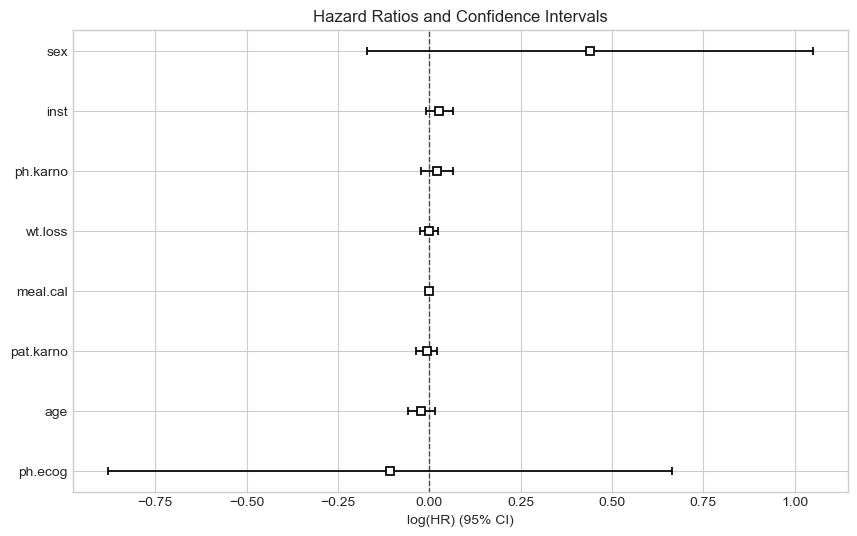

In [13]:
# Plotting the effect of covariates
plt.figure(figsize=(10, 6))
cph.plot()
plt.title("Hazard Ratios and Confidence Intervals")
plt.show()

### Prediction
We can use the fitted model to predict survival curves for specific individuals.

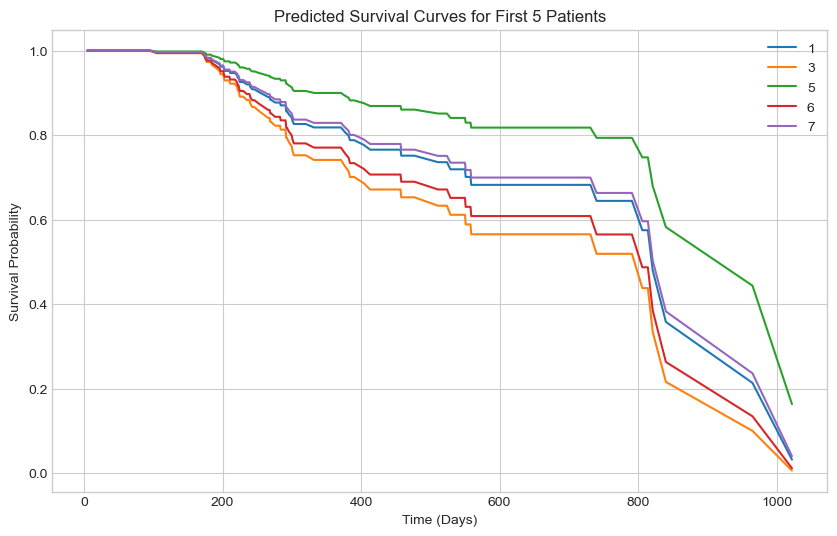

In [14]:
# Predict survival function for the first 5 patients
cph.predict_survival_function(data.head(5)).plot(figsize=(10, 6))
plt.title("Predicted Survival Curves for First 5 Patients")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.show()

## Conclusion
We have covered:
1. **KM Estimator**: Visualizing survival over time.
2. **Log-Rank Test**: Comparing groups statistically.
3. **Cox PH Model**: Quantifying the effect of multiple variables on survival.

Next steps: Advanced Machine Learning models for survival analysis.